**Goal:** see a convolution do its work, then build a small **convolutional neural network** and watch
it beat a plain MLP on images. You will convolve a kernel by hand and confirm PyTorch agrees, watch a
filter act as an edge detector, assemble a `Conv -> ReLU -> Pool` network and trace its shapes, and
train it on Fashion-MNIST. Everything runs on CPU in tens of seconds (the one-time dataset download
aside). Pairs with the concept note [Convolutional Neural Networks](l18_concept_cnn.qmd).

> **Previously:** L17 -- Training Deep Networks (init, optimizers, regularizers)  |  **Next:** L19 -- CNN Architectures & Transfer Learning

> This page is the read-only view. To run the lab, open the notebook
> (`l18_lab_cnn.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

An MLP flattens a 28x28 image into 784 numbers and forgets which pixel sat next to which. A CNN keeps
the grid: it slides small learnable **filters** across the image, building **feature maps** that say
where each pattern fires, and **pools** to shrink them. We will first strip convolution down to
multiply-and-sum on a 4x4 patch, then scale up to a real classifier on Fashion-MNIST and measure the
gap against the MLP.

## Setup

Two cells: the first installs, the second imports, seeds, loads the data, and defines train/eval helpers.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships torch, torchvision and matplotlib, so this is effectively a no-op there.
%pip install -q torch torchvision matplotlib
# local, in a terminal (not in the notebook):  uv add torch torchvision matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS + DATA + HELPERS (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42); np.random.seed(42)

tfm = transforms.ToTensor()                                   # PIL image -> [1, 28, 28] tensor in [0, 1]
train_full = torchvision.datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
test_set   = torchvision.datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
CLASSES = train_full.classes

def take(ds, n, seed=42):
    """A seed-locked subset of n examples (keeps the lab fast on CPU)."""
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g)[:n]
    return Subset(ds, idx.tolist())

train_set = take(train_full, 20000)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(0))
test_loader  = DataLoader(test_set, batch_size=512)

def train(model, loader, epochs, lr=1e-3):
    """Mini-batch training (the L15 loop, now over batches); returns the per-epoch loss curve."""
    opt = torch.optim.Adam(model.parameters(), lr=lr); loss_fn = nn.CrossEntropyLoss()
    curve = []
    for epoch in range(epochs):
        model.train(); running = 0.0
        for xb, yb in loader:
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
            running += loss.item() * len(xb)
        curve.append(running / len(loader.dataset))
    return curve

def test_acc(model):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            correct += (model(xb).argmax(1) == yb).sum().item(); total += len(yb)
    return correct / total

print(f"train {len(train_set)} (subset) / test {len(test_set)} images; {len(CLASSES)} classes")

train 20000 (subset) / test 10000 images; 10 classes


~~~text
train 20000 (subset) / test 10000 images; 10 classes
~~~

## Step 1: Convolution by Hand

A convolution is multiply-and-sum: lay a small **kernel** over each patch of the image, multiply
element-wise, and sum. Zero-pad the border so the output keeps the input's size, and step with a
**stride** of 1. Here is the source's 4x4 image `M` convolved with a horizontal-line kernel:

In [3]:
def convolve2D(image, kernel):
    ih, iw = image.shape; kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), "constant")   # zero padding
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(ih):
        for j in range(iw):
            out[i, j] = np.sum(padded[i:i + kh, j:j + kw] * kernel)   # multiply-and-sum, stride 1
    return out

M = np.array([[10, 24, 20, 175], [8, 5, 4, 184], [184, 174, 223, 201], [55, 89, 55, 192]], dtype=np.float32)
K = np.array([[0, 0, 0], [1, 1, 1], [0, 0, 0]], dtype=np.float32)   # a horizontal-line kernel
print("feature map M * K =\n", convolve2D(M, K))

Mt = torch.tensor(M).reshape(1, 1, 4, 4); Kt = torch.tensor(K).reshape(1, 1, 3, 3)
print("F.conv2d agrees:", np.allclose(F.conv2d(Mt, Kt, padding=1)[0, 0].numpy(), convolve2D(M, K)))

feature map M * K =
 [[ 34.  54. 219. 195.]
 [ 13.  17. 193. 188.]
 [358. 581. 598. 424.]
 [144. 199. 336. 247.]]
F.conv2d agrees: True


~~~text
feature map M * K =
 [[ 34.  54. 219. 195.]
 [ 13.  17. 193. 188.]
 [358. 581. 598. 424.]
 [144. 199. 336. 247.]]
F.conv2d agrees: True
~~~

Each output is the sum of the three vertically-stacked neighbors the horizontal kernel covers. PyTorch's
`F.conv2d` does exactly the same thing (on 4-D `NCHW` tensors), just fast.

## Step 2: A Filter Is a Pattern Detector

Filters detect patterns. Send a synthetic bright square through a **vertical-edge** kernel (negative
column, zero, positive column) and read where it fires:

In [4]:
square = torch.zeros(1, 1, 6, 6); square[0, 0, 1:5, 1:5] = 1.0       # a white square on black
v_kernel = torch.tensor([[[[-1., 0, 1], [-1, 0, 1], [-1, 0, 1]]]])   # vertical-edge detector
fmap = F.conv2d(square, v_kernel, padding=1)
print("feature map shape:", tuple(fmap.shape))
print("vertical-edge map:\n", fmap[0, 0].numpy())

feature map shape: (1, 1, 6, 6)
vertical-edge map:
 [[ 1.  1.  0.  0. -1. -1.]
 [ 2.  2.  0.  0. -2. -2.]
 [ 3.  3.  0.  0. -3. -3.]
 [ 3.  3.  0.  0. -3. -3.]
 [ 2.  2.  0.  0. -2. -2.]
 [ 1.  1.  0.  0. -1. -1.]]


~~~text
feature map shape: (1, 1, 6, 6)
vertical-edge map:
 [[ 1.  1.  0.  0. -1. -1.]
 [ 2.  2.  0.  0. -2. -2.]
 [ 3.  3.  0.  0. -3. -3.]
 [ 3.  3.  0.  0. -3. -3.]
 [ 2.  2.  0.  0. -2. -2.]
 [ 1.  1.  0.  0. -1. -1.]]
~~~

The filter is **positive on the square's left edge, negative on its right edge, and zero across the
flat interior** -- it responds to vertical edges wherever they are (translation invariance), and stays
silent on flat regions. In a real CNN these filters are not hand-set; they are **learned by backprop**.

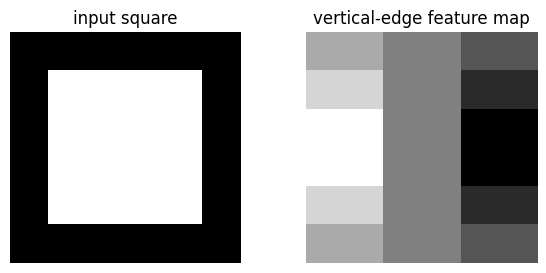

In [5]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1); plt.imshow(square[0, 0], cmap="gray"); plt.title("input square"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fmap[0, 0], cmap="gray"); plt.title("vertical-edge feature map"); plt.axis("off")
plt.show()

## Step 3: Build a CNN and Trace Its Shapes

Stack two `Conv -> ReLU -> MaxPool` blocks, then `Flatten` and two dense layers. Padding keeps each
conv's height and width; only pooling shrinks them, so the size halves at each pool (28 -> 14 -> 7).
Trace the shapes to find the flattened dimension that feeds the first dense layer:

In [6]:
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 28 -> 14
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 14 -> 7
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128), nn.ReLU(),                          # 64*7*7 = 3136
        nn.Linear(128, 10),                                             # logits
    )

cnn = make_cnn()
x = torch.zeros(1, 1, 28, 28)
for layer in cnn:
    x = layer(x)
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.Flatten, nn.Linear)):
        print(f"  after {layer.__class__.__name__:9s}: {tuple(x.shape)}")
print("conv1 params:", sum(p.numel() for p in cnn[0].parameters()),
      " conv2 params:", sum(p.numel() for p in cnn[3].parameters()))
print("CNN total params:", sum(p.numel() for p in cnn.parameters()))

  after Conv2d   : (1, 32, 28, 28)
  after MaxPool2d: (1, 32, 14, 14)
  after Conv2d   : (1, 64, 14, 14)
  after MaxPool2d: (1, 64, 7, 7)
  after Flatten  : (1, 3136)
  after Linear   : (1, 128)
  after Linear   : (1, 10)
conv1 params: 320  conv2 params: 18496
CNN total params: 421642


~~~text
  after Conv2d   : (1, 32, 28, 28)
  after MaxPool2d: (1, 32, 14, 14)
  after Conv2d   : (1, 64, 14, 14)
  after MaxPool2d: (1, 64, 7, 7)
  after Flatten  : (1, 3136)
  after Linear   : (1, 128)
  after Linear   : (1, 10)
conv1 params: 320  conv2 params: 18496
CNN total params: 421642
~~~

Note how few weights the convolutional layers hold: **320** and **18,496**, because each filter is
shared across all positions. A dense layer wiring 784 pixels to 32x784 outputs would have *millions*.
The bulk of the CNN's parameters live in the dense head, not the convolutions.

Before training, make sure you can read that flattened dimension straight off the spatial trace --
it is the one number you must get right to wire a CNN into a dense head:

In [7]:
# Your turn (warm-up): from the 28 -> 14 -> 7 trace, predict the flattened size that feeds the
# first dense layer, then check it. Uncomment and fill the blank:
# flat_dim = ____                          # 64 feature maps of 7 x 7
# assert flat_dim == cnn[7].in_features    # cnn[7] is the first nn.Linear
# print("flattened dimension:", flat_dim)

The blank is `64 * 7 * 7`, which is `3136` -- exactly the `after Flatten` shape above and the first
`nn.Linear`'s `in_features`.

## Step 4: Train It, and Beat the MLP

Train the CNN on the 20k subset for 5 epochs, then train the L15-style **MLP** on the same data and
compare. (The CNN takes ~20 s on CPU; the MLP is quicker.)

In [8]:
torch.manual_seed(0); cnn = make_cnn()
cnn_curve = train(cnn, train_loader, epochs=5)
print(f"CNN test accuracy: {test_acc(cnn):.4f}")
print("CNN loss curve:", " ".join(f"{l:.3f}" for l in cnn_curve))

CNN test accuracy: 0.8886
CNN loss curve: 0.618 0.384 0.321 0.288 0.262


~~~text
CNN test accuracy: 0.8886
CNN loss curve: 0.618 0.384 0.321 0.288 0.262
~~~

In [9]:
def make_mlp():
    return nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 256), nn.ReLU(),
                         nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10))
torch.manual_seed(0); mlp = make_mlp()
mlp_curve = train(mlp, train_loader, epochs=5)
print(f"MLP params: {sum(p.numel() for p in mlp.parameters())}")
print(f"MLP test accuracy: {test_acc(mlp):.4f}")

MLP params: 235146


MLP test accuracy: 0.8597


~~~text
MLP params: 235146
MLP test accuracy: 0.8597
~~~

The CNN reaches **0.889** against the MLP's **0.860** on the same images -- a clear, reproducible win.
The MLP plateaus near 0.86 no matter how it is tuned; the CNN keeps climbing, because convolution and
pooling exploit the 2-D structure and translation invariance the MLP throws away when it flattens.

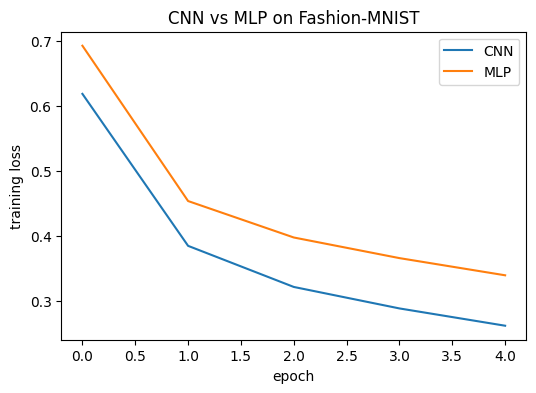

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(cnn_curve, label="CNN"); plt.plot(mlp_curve, label="MLP")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend()
plt.title("CNN vs MLP on Fashion-MNIST"); plt.show()

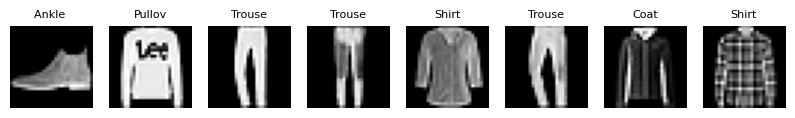

In [11]:
# a few test images with the CNN's predictions
cnn.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = cnn(xb[:8]).argmax(1)
plt.figure(figsize=(10, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1); plt.imshow(xb[i, 0], cmap="gray"); plt.axis("off")
    plt.title(f"{CLASSES[pred[i]][:6]}", fontsize=8)
plt.show()

## Your Turn

### Exercise 1 -- Regularize the CNN (L17 tricks)

Add `nn.BatchNorm2d` after each convolution and a `nn.Dropout(0.3)` before the dense head (the L17
toolkit, now on a CNN). Build this regularized model, train it for 5 epochs on the same data, and
compare its test accuracy to the plain CNN's 0.889.

**Hint:** insert `nn.BatchNorm2d(32)` after the first conv and `nn.BatchNorm2d(64)` after the second
(before each ReLU), and `nn.Dropout(0.3)` right after `nn.Flatten()`. Re-seed `torch.manual_seed(0)`
before building, then reuse `train(...)` and `test_acc(...)`. Run the setup and Step 4 cells first --
the exact accuracy depends on the shared `train_loader`'s prior random draws, so re-running just this
cell in isolation gives a slightly different number (the takeaway is the comparison, not the last digit).

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
CNN+BN+Dropout test accuracy: 0.8985
~~~

The regularized model builds `nn.Sequential(nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
nn.MaxPool2d(2), nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
nn.Flatten(), nn.Dropout(0.3), nn.Linear(64*7*7,128), nn.ReLU(), nn.Linear(128,10))`. BatchNorm and
dropout (L17) push the CNN from 0.889 to about 0.899 -- the training toolkit stacks on top of the
architecture.
</details>

### Exercise 2 -- Average pooling instead of max

Swap both `nn.MaxPool2d(2)` for `nn.AvgPool2d(2)` in the plain CNN, retrain for 5 epochs, and compare.
Which pooling keeps the sharper features here?

**Hint:** copy `make_cnn` and replace the two `nn.MaxPool2d(2)` with `nn.AvgPool2d(2)`; re-seed
`torch.manual_seed(0)` and reuse `train(...)` / `test_acc(...)`. As in Ex1, run top-to-bottom first --
the exact number depends on the shared loader's prior draws.

In [13]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
CNN (AvgPool) test accuracy: 0.8778
~~~

Average pooling reaches about 0.878, a little below max pooling's 0.889. Max pooling keeps the
strongest activation in each window -- the clearest evidence that a feature is present -- while
averaging blurs it; max pooling is the more common default for this reason.
</details>

## Summary

- A **convolution** is multiply-and-sum: a small **kernel** slid over each patch makes a **feature
  map**; `F.conv2d` matched our by-hand `convolve2D` exactly.
- A filter is a **pattern detector** -- the vertical-edge kernel fired on edges (+/-) and was silent on
  flat regions -- and the same filter is reused everywhere (**parameter sharing**, **translation
  invariance**). Real filters are **learned by backprop**.
- A CNN stacks `Conv -> ReLU -> Pool` blocks (spatial trace **28 -> 14 -> 7**), then
  `Flatten -> Dense -> logits`; its conv layers held only **320** and **18,496** weights.
- On the same Fashion-MNIST images the CNN reached **0.889** vs the MLP's **0.860** -- it exploits 2-D
  structure the MLP discards. Adding L17's **BatchNorm + dropout** pushed it to **0.899**; **max**
  pooling beat **average** pooling (0.889 vs 0.878).
- Next (L19): assembling these layers into famous architectures (ResNet's residual connections) and
  reusing models pretrained on millions of images -- **transfer learning**.